In [82]:
source("/maps/projects/perslab/people/lhv464/glp1r_leptin/R/basic_processing.R")
source("/maps/projects/perslab/people/lhv464/glp1r_leptin/R/analysis_wrappers.R")
source("/maps/projects/perslab/people/lhv464/glp1r_leptin/R/helper_functions.R")

library(org.Hs.eg.db)
library(miloR)
library(SingleCellExperiment)
library(tidyverse)
library(DESeq2)
library(Seurat)

targets::tar_load("arc_diet_labeled", store = "/maps/projects/perslab/people/lhv464/glp1r_leptin/_targets/")
targets::tar_load("arc_lepip", store = "/maps/projects/perslab/people/lhv464/glp1r_leptin/_targets/")

arc_lepip <- process_seurat(arc_lepip, method = "integrate", batch = "orig.ident", res = 30, dims = 30)  %>% 
    project_umap(query = ., ref = arc_diet_labeled, dims = 30, label_to_transfer="seurat_clusters", 
                 reference.assay = "integrated", query.assay = "integrated") 
arc_lepip$predicted.celltype <- str_replace_all(arc_lepip$predicted.celltype, c("32" = "Irx3", "28" = "Irx3", "21" = "Irx3"))  # Just for Irx3

arc_lepip_backup <- arc_lepip

Scaling features for provided objects

Computing within dataset neighborhoods

Finding all pairwise anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 4686 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 4328 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 4837 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1876 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 2004 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1977 anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1888 anchors

Projecting new data onto SVD

Projecting new

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 58744
Number of edges: 3673117

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6809
Number of communities: 239
Elapsed time: 17 seconds


Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 31213 anchors

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”

Integrating dataset 2 with reference dataset

Finding integration vectors

Integrating data

Computing nearest neighbors

Running UMAP projection

11:08:01 Read 58744 rows

11:08:01 Processing block 1 of 1

11:08:01 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:08:02 Initializing by weighted average of neighbor coordinates using 1 thread

11:08:02 Commencing optimization for 67 epochs, with 1762286 positive edges

11:08:07 Finished



In [95]:
arc_lepip <- arc_lepip_backup
arc_lepip <- subset(arc_lepip, time == 24) # Rotating between time points here, then rerunning script

milo_lepip <- seurat_to_milo(arc_lepip, pca_reduction_name = "pca", umap_reduction_name = "umap")

Warning message:
“Removing 11735 cells missing data for vars requested”
Constructing kNN graph with k:30

Checking valid object

Running refined sampling with graph

Checking meta.data validity

Counting cells in neighbourhoods



In [96]:
design <- data.frame(colData(milo_lepip))[,c("ObsID", "group", "orig.ident")]
design <- distinct(design)
rownames(design) <- design$ObsID
## Reorder rownames to match columns of nhoodCounts(milo)
design <- design[colnames(nhoodCounts(milo_lepip)), , drop=FALSE]
contrastHFD <- c("(groupmut_Lep - groupmut_Sal) - (groupwt_Lep - groupwt_Sal)") 
contrastFast <- c("(groupwt_Lep) - (groupwt_Sal)") 

# we need to use the ~ 0 + Variable expression here so that we have all of the levels of our variable as separate columns in our model matrix
da_results_hfd <- testNhoods(milo_lepip, design = ~ 0 + group, design.df = design, model.contrasts = contrastHFD,
                         fdr.weighting="graph-overlap", norm.method="TMM")
da_results_fast <- testNhoods(milo_lepip, design = ~ 0 + group , design.df = design, model.contrasts = contrastFast,
                         fdr.weighting="graph-overlap", norm.method="TMM")

da_results_hfd <- annotateNhoods(milo_lepip, da_results_hfd,  coldata_col = "predicted.celltype")
da_results_hfd <- annotateNhoods(milo_lepip, da_results_hfd,  coldata_col = "group")

da_results_fast <- annotateNhoods(milo_lepip, da_results_fast,  coldata_col = "predicted.celltype")
da_results_fast <- annotateNhoods(milo_lepip, da_results_fast,  coldata_col = "group")
da_results_fast %>% arrange(SpatialFDR)  %>%  head

Using TMM normalisation

Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Performing spatial FDR correction withgraph-overlap weighting

Using TMM normalisation

Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Performing spatial FDR correction withgraph-overlap weighting

Converting predicted.celltype to factor...

Converting group to factor...

Converting predicted.celltype to factor...

Converting group to factor...



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,predicted.celltype,predicted.celltype_fraction,group,group_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>
278,-3.250697,12.24221,16.77632,4.229491e-05,0.01032479,278,0.01154083,36,0.5571429,wt_Sal,0.5142857
297,-3.742144,12.03805,17.39740,3.429348e-05,0.01032479,297,0.01154083,Irx3,0.9387755,wt_Sal,0.6734694
350,-3.656629,12.12980,16.47057,5.611302e-05,0.01032479,350,0.01154083,Irx3,0.9444444,wt_Sal,0.5740741
129,-3.512787,12.07038,15.48953,8.337037e-05,0.01150511,129,0.01172399,36,0.7454545,wt_Sal,0.5090909
4,-2.775590,12.05282,10.98026,9.569608e-04,0.07169907,4,0.01592023,Irx3,0.9387755,wt_Sal,0.5510204
66,-2.103640,12.44223,10.34095,1.304107e-03,0.07169907,66,0.01592023,6,1.0000000,wt_Sal,0.4827586


In [97]:
# create neighborhood pseudobulk
nh_matrix <- nhoods(milo_lepip)
colnames(nh_matrix) <- 1:ncol(nh_matrix)

# create gene expression by neighborhood matrix
signature_scores <- arc_lepip@assays$RNA@counts
score_sums <- t(Matrix::t(nh_matrix) %*% Matrix::t(signature_scores))

dds <- DESeqDataSetFromMatrix(score_sums, 
                              colData = da_results_hfd, 
                              design = ~predicted.celltype+group)
                              
keep <- rowSums(counts(dds) >= 5) >= 20
table(keep)
dds_filtered <- dds[keep, ]
dds_filtered
vsd <- vst(dds_filtered, blind=FALSE)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


keep
FALSE  TRUE 
11319 14957 

class: DESeqDataSet 
dim: 14957 552 
metadata(1): version
assays(1): counts
rownames(14957): Xkr4 Gm1992 ... Apela mt-Co3
rowData names(0):
colnames(552): 1 2 ... 551 552
colData names(11): logFC logCPM ... group group_fraction

In [23]:
# prep data for magma

spm_scores <- assay(vsd)[!grepl("Gm|mt-|Rik", rownames(assay(vsd))),]

genes_converted <- data.frame(convert_mouse_to_human(rownames(spm_scores))) %>% filter(!duplicated(X1))

genes_entrez <- AnnotationDbi::select(org.Hs.eg.db,
                            keys = unique(genes_converted$X2),
                            columns = c("ENTREZID","ENSEMBL", "SYMBOL"),
                            keytype = "SYMBOL")  %>% 
                            filter(!duplicated(SYMBOL))

humdeg <- inner_join(genes_entrez, genes_converted, by=c("SYMBOL" = "X2"))  %>% 
    inner_join(spm_scores  %>% data.frame()  %>% janitor::clean_names()  %>%  rownames_to_column("mouse_gene"), by=c("X1"="mouse_gene"))  %>% dplyr::select(c(-SYMBOL,-X1,-ENSEMBL))  %>%
    dplyr::rename(GENE=ENTREZID)  %>% 
    filter(!duplicated(GENE), !is.na(GENE)) 

humdeg$Average <- rowMeans(humdeg[,-1])

write.table(humdeg, file="/projects/perslab/people/jmg776/ad_hoc/dylan_MAGMA-milo/milo_lepinject.txt", sep = "\t", quote=F, row.names=F)

'select()' returned 1:many mapping between keys and columns



In [ ]:
# Run this in a terminal after initial magma run. 

magma --gene-results /projects/perslab/apps/MAGMA/out/SystolicBP_GCST90310294/SystolicBP_GCST90310294.genes.raw \
      --gene-covar /projects/perslab/people/jmg776/ad_hoc/dylan_MAGMA-milo/milo_lepinject.txt \
      --model direction=greater condition-hide=Average --out /projects/perslab/people/jmg776/ad_hoc/dylan_MAGMA-milo/SystolicBP_leprinject_gwas_milo

In [98]:
# Get proportions of cells per condition in a neighborhood
# Create a dummy matrix for groups
group_matrix <- model.matrix(~ 0 + factor(colData(milo_lepip)$group))
colnames(group_matrix) <- levels(factor(colData(milo_lepip)$group))
  
# Perform matrix multiplication
result <- t(group_matrix) %*% nh_matrix

# Calculate column sums
col_sums <- colSums(result)

# Calculate proportions
proportions <- sweep(result, 2, col_sums, FUN = "/")  %>% 
    data.frame()  %>% 
    rownames_to_column("group")  %>% 
    pivot_longer(-group)  %>% 
    mutate(name = gsub("X","", name))


New names:
• `Nhood` -> `Nhood...1`
• `Nhood` -> `Nhood...10`
`geom_smooth()` using formula = 'y ~ x'
New names:
• `Nhood` -> `Nhood...1`
• `Nhood` -> `Nhood...10`
`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

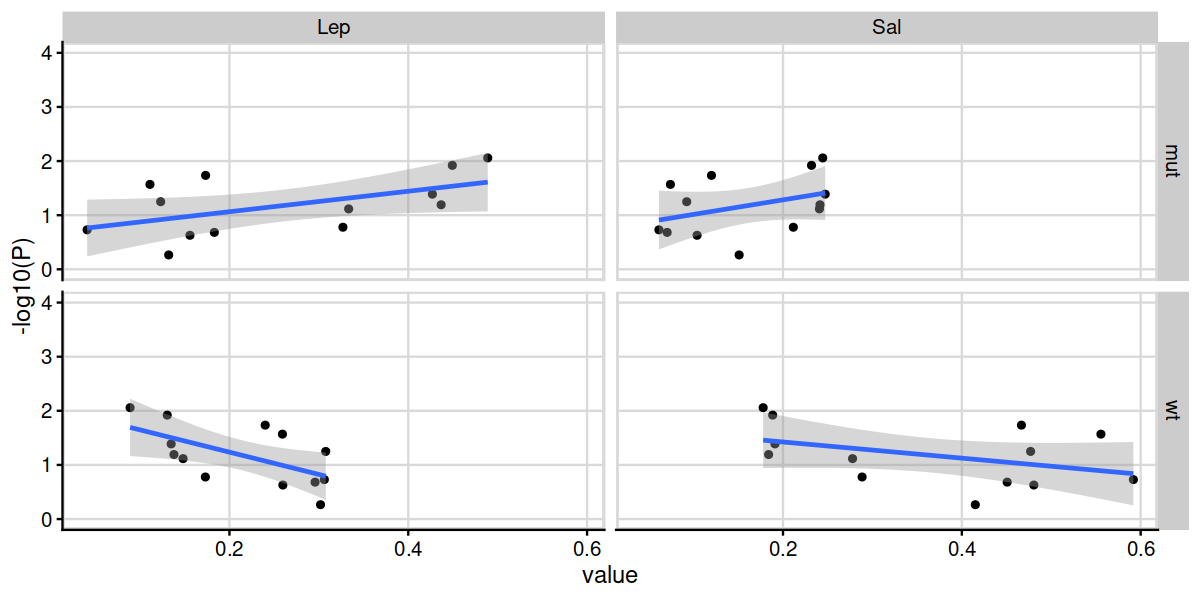

In [99]:
# read in magma results
gwas <- "SystolicBP_lepinject24"
res <- read.table(paste0("/projects/perslab/people/jmg776/ad_hoc/dylan_MAGMA-milo/", gwas, "_gwas_milo.gsa.out"), header=T) %>%  data.frame()  %>% 
    mutate(VARIABLE = gsub("X","", VARIABLE))  %>% 
    dplyr::rename(Nhood=VARIABLE)  %>% 
    dplyr::select(Nhood, BETA, P)   %>% 
    mutate(padj = p.adjust(P)) 

# res  %>% bind_cols(da_results_hfd)  %>% 
#     group_by(predicted.celltype)  %>% 
#     summarise(mean = max(-log10(P)))  %>% 
#     arrange(desc(mean))

# a <- res  %>% bind_cols(da_results_hfd)  %>% mutate(logFCwt = da_results_fast$logFC, nhood = as.character(`Nhood...10`))  %>% 
#     inner_join(proportions, by=c("nhood"="name"))  %>% 
#     filter(predicted.celltype%in%c("1")), predicted.celltype_fraction>0.7, value>0.1) %>% 
#     group_by(group.y)  %>% 
#     #summarise(cor = cor(-log10(P), value))
#     nest(-group.y)  %>%  
#     mutate(res = purrr::map(data, function(x) lm(-log10(P) ~ value, data=x)  %>% broom::tidy(.)))  %>%  unnest(res) %>%
#     select(-data)
# write_tsv(a, paste0("/projects/perslab/people/jmg776/ad_hoc/dylan_MAGMA-milo/", gwas, "_significance.tsv"))
res  %>% bind_cols(da_results_hfd)  %>% mutate(logFCwt = da_results_fast$logFC, nhood = as.character(`Nhood...10`))  %>% 
    inner_join(proportions, by=c("nhood"="name"))  %>% 
    filter(predicted.celltype%in%c("12"), predicted.celltype_fraction>0.7, value>0) %>% 
    separate(group.y, into = c("geno", "diet"))  %>% 
    ggplot() +
    aes(x=value, y= -log10(P))+ geom_point() +
    geom_smooth(method="lm") + 
    coord_cartesian(ylim = c(0, 4)) +
    facet_grid(vars(geno), vars(diet)) +
    cowplot::theme_half_open() + cowplot::background_grid() + cowplot::panel_border()

pdf("Lep-inj-24_GWAS-systolicBP.pdf", width = 10, height = 10)
res  %>% bind_cols(da_results_hfd)  %>% mutate(logFCwt = da_results_fast$logFC, nhood = as.character(`Nhood...10`))  %>% 
    inner_join(proportions, by=c("nhood"="name"))  %>% 
    filter(predicted.celltype%in%c("12"), predicted.celltype_fraction>0.7, value>0) %>% 
    separate(group.y, into = c("geno", "diet"))  %>% 
    ggplot() +
    aes(x=value, y= -log10(P))+ geom_point() +
    geom_smooth(method="lm") + 
    coord_cartesian(ylim = c(0, 4)) +
    facet_grid(vars(geno), vars(diet)) +
    cowplot::theme_half_open() + cowplot::background_grid() + cowplot::panel_border()
dev.off()